In [1]:
# Put import statements here
import sys
import subprocess
from pathlib import Path

# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
from src.util.config import config, PROJECT_ROOT
import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# Run pytest setup tests to verify the environment/hardware is good to go
#subprocess.run(
#    [sys.executable, "-m", "pytest", "-q", "test/test_setup.py"],
#    check=False,
#)

In [3]:
# Determine the project's data repo location
DATA_DIR= PROJECT_ROOT / "data"


In [4]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / config.data.PlantExpertVQA.data_path
train_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.train_file
test_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.test_file
validation_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.validation_file


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

21:08:36 [DEBUG   ]: [load_csv] Successfully loaded /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/Users/codygould/PycharmProjects/PlantQA/src/data_preprocessing/text_preprocessing.py:27: DtypeWarning: Columns (0: answer_type) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


21:08:36 [DEBUG   ]: [load_csv] Successfully loaded /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
21:08:36 [DEBUG   ]: [load_csv] Successfully loaded /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [5]:
PEVQA_text_columns= general_util.parse_list_from_string(config.data.PlantExpertVQA.text_columns)
PEVQA_columns_to_remove= general_util.parse_list_from_string(config.data.PlantExpertVQA.columns_to_remove)
PEVQA_na_fill= vars(config.data.PlantExpertVQA.na_fill)

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill
)


<class 'pandas.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   qa_id              535881 non-null  str  
 1   image_id           535881 non-null  str  
 2   image_path         535881 non-null  str  
 3   crop               535881 non-null  str  
 4   disease            535881 non-null  str  
 5   category           535881 non-null  str  
 6   severity           535881 non-null  str  
 7   question_text      535881 non-null  str  
 8   answer             535881 non-null  str  
 9   answer_type        535881 non-null  str  
 10  question_category  535881 non-null  str  
 11  cognitive_level    535881 non-null  str  
dtypes: str(12)
memory usage: 49.1 MB
21:08:42 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



21:08:43 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                       qa_id              image_id 

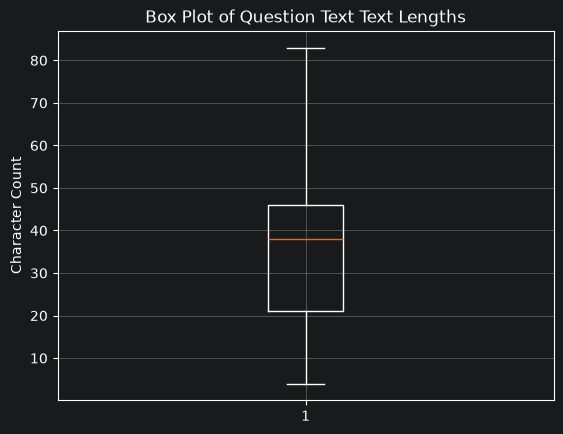

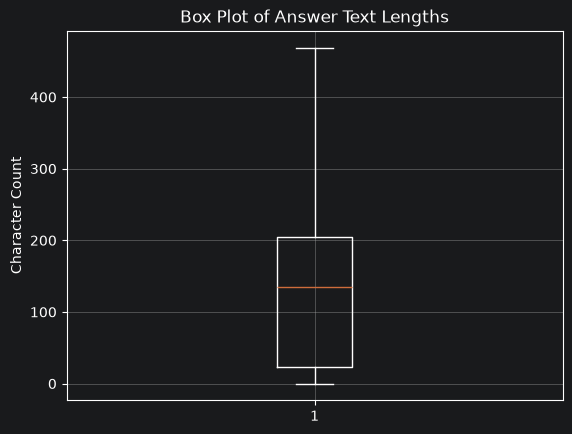







21:08:43 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




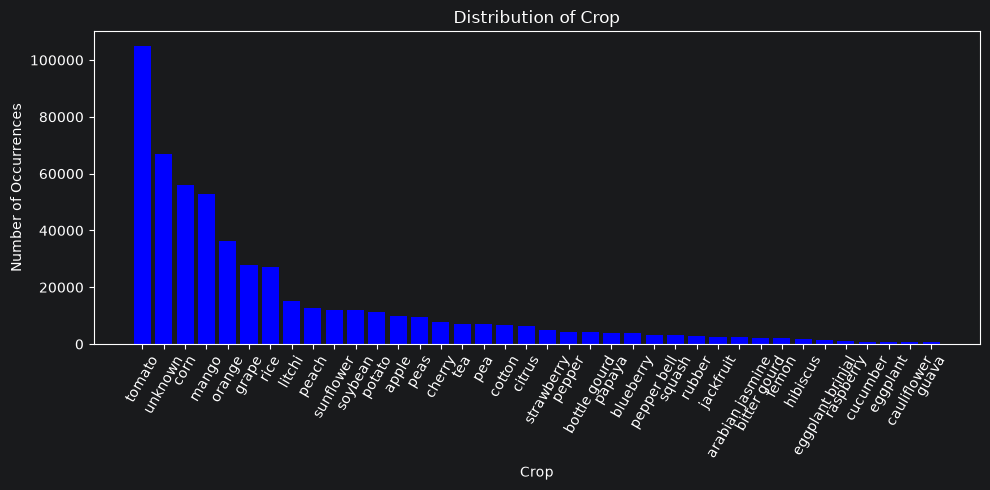

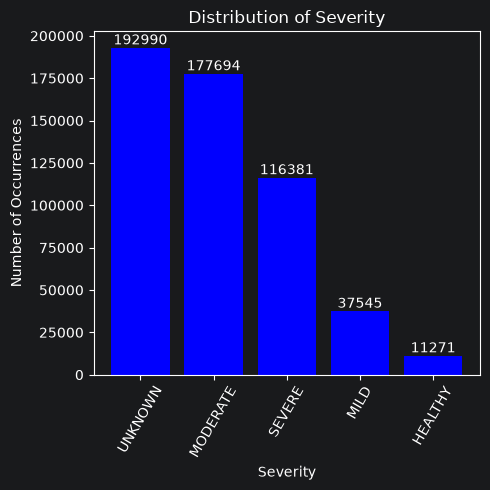

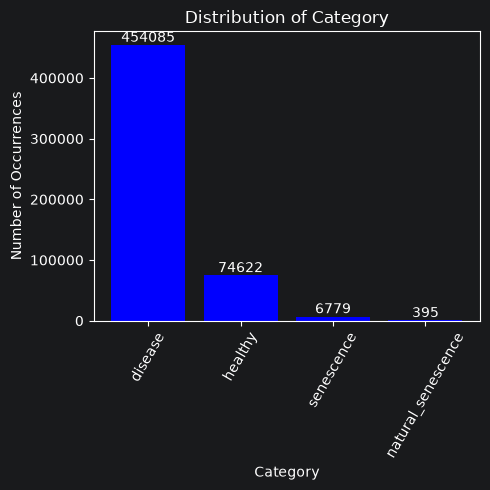

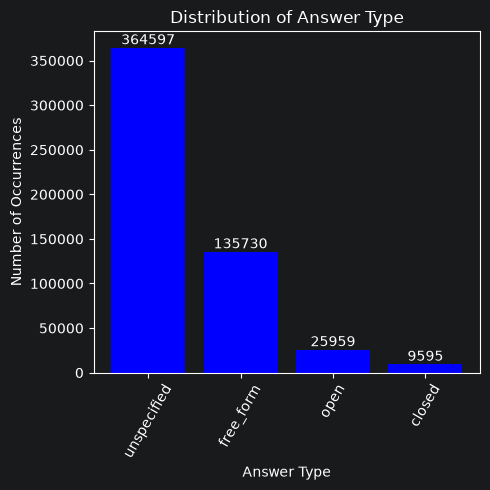

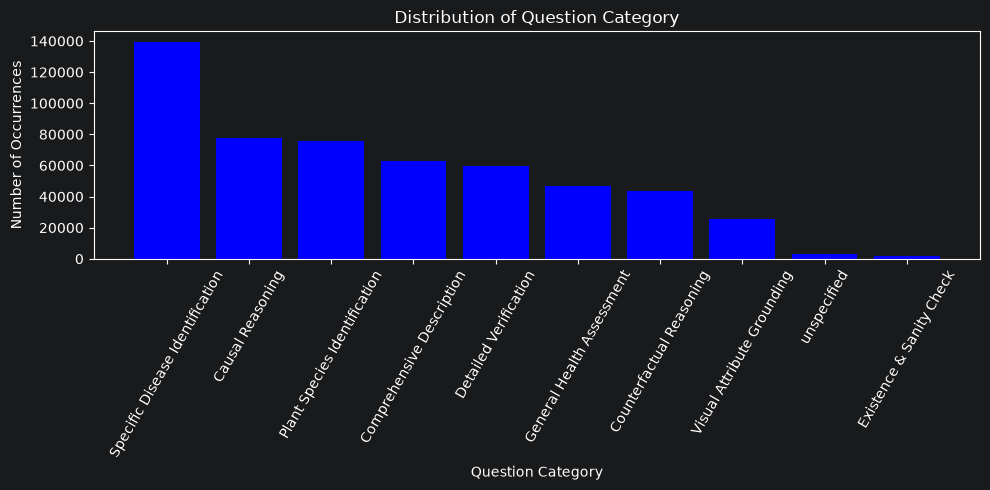







21:08:43 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




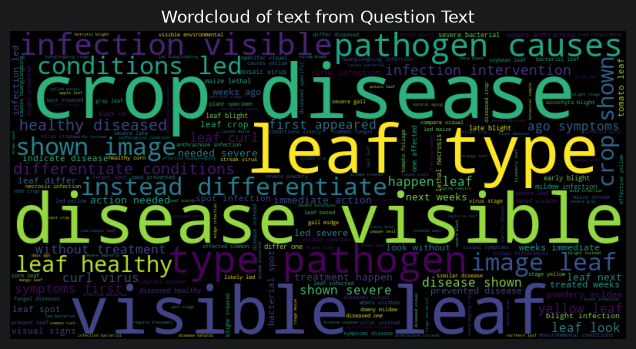

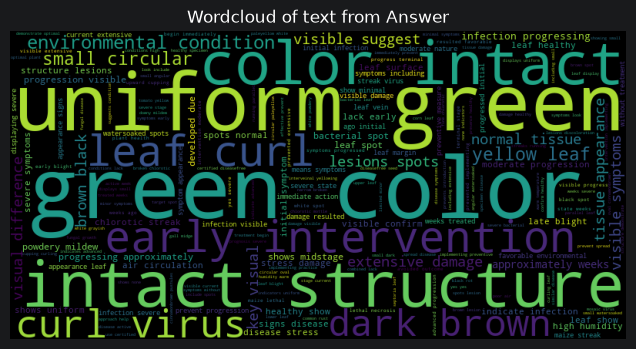







21:08:51 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




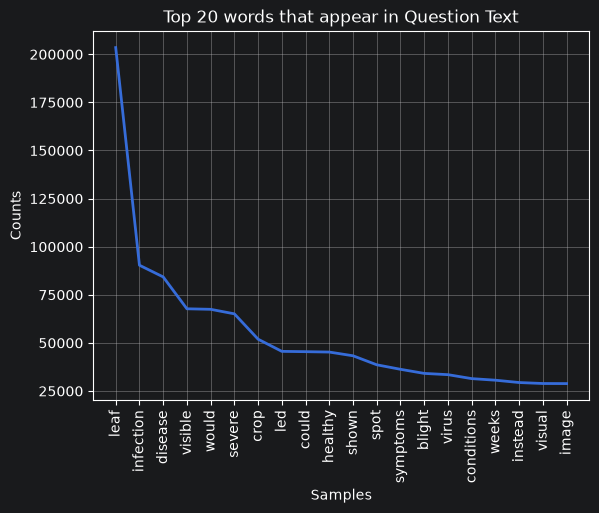

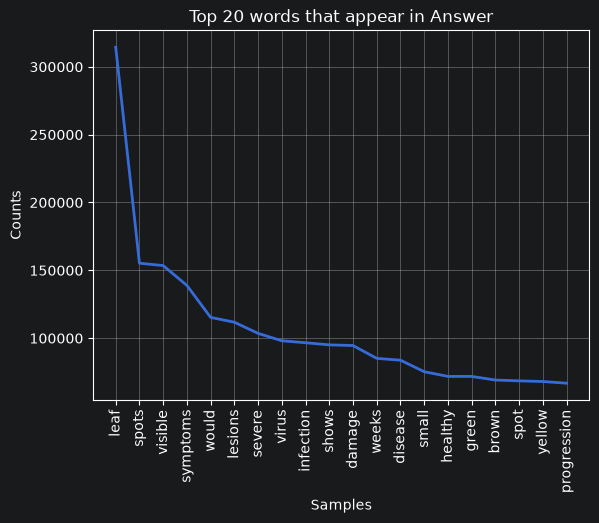

In [6]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    PEVQA_text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [7]:
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

encoding= tokenizer.encode_text("hello", None)

Logger.info(encoding)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

21:08:54 [INFO    ]: {'input_ids': [[101, 7592, 102]], 'token_type_ids': [[0, 0, 0]], 'attention_mask': [[1, 1, 1]]}


21:08:54 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg


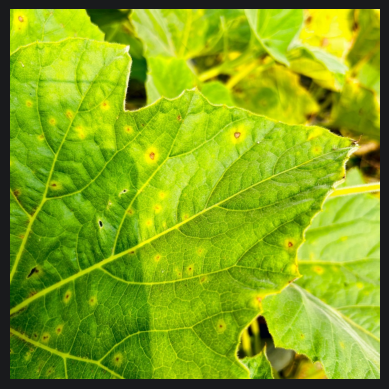

In [8]:
head= plant_expert_vqa_TRAIN.iloc()[0]
image_path= head["image_path"]
full_image_path= DATA_DIR / "PlantExpertVQA" / image_path
img= img_pre.load_image(full_image_path)

img_pre.show_image(img)

In [9]:
# Adding on macbook - will need to retest on workstation later tonight due to GPU acceleration
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"
traits = ["crop", "disease", "category", "severity"]

classes = {}
for t in traits:
    names = sorted(plant_expert_vqa_TRAIN[t].unique()) # adds names of plants
    classes[t] = names + ["unknown"] # adds unknown species

train_ds = VisualModel.make_dataset(plant_expert_vqa_TRAIN, classes, IMAGES_ROOT, training=True)
val_ds = VisualModel.make_dataset(plant_expert_vqa_VAL,   classes, IMAGES_ROOT)

visual_model = VisualModel(classes=classes)
visual_model.build()
visual_model.compile()
visual_model.fit(train_ds, val_ds, epochs=20)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


/Users/codygould/PycharmProjects/PlantQA/venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/5d4ff547521c6c4e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/5d4ff547521c6c4e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg
21:09:01 [DEBUG   ]: Loaded image: /Users/codygould/PycharmProjects/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg
21:09:01

KeyboardInterrupt: 